# Notebook 00 — Descarga de datos satelitales y vectoriales

Este notebook descarga datos **reales** y los persiste localmente en `python/data/` para que el resto del taller corra **offline**.

## Fuentes

### Raster (Sentinel-2 L2A)
**Microsoft Planetary Computer** — catálogo STAC público sin autenticación.
- Catálogo: `https://planetarycomputer.microsoft.com/api/stac/v1`
- Colección: `sentinel-2-l2a` (superficie reflectancia, corregida atmosféricamente)
- Documentación: https://planetarycomputer.microsoft.com/datasets/sentinel-2-l2a
- Bandas utilizadas: **B02** (Blue, 10 m), **B03** (Green, 10 m), **B04** (Red, 10 m), **B08** (NIR, 10 m)
- Filtros: nubosidad `< 20%`, período 2024-01-01 / 2025-12-31, AOI Sabana de Bogotá
- Si la búsqueda falla se amplia el filtro a 40% y se documenta en una celda siguiente.

### Vectores (OpenStreetMap)
**OpenStreetMap** vía librería `osmnx` (Overpass API pública).
- Geocodificación: `"Bogotá, Colombia"` (Nominatim)
- POIs: features con tag `tourism` (atracciones, miradores, parques)
- Rutas: grafo vial `drive` (edges reducidos a una muestra representativa)

## 1. Instalación de dependencias

Si ejecutas el taller en un entorno limpio, descomenta la siguiente celda. Para este taller ya se encuentran instaladas en el `.venv` del proyecto.

In [1]:
# %pip install pystac-client planetary-computer rioxarray xarray rasterio geopandas \
#              shapely pyproj fiona folium osmnx matplotlib numpy pillow requests

In [2]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import requests
import rioxarray
import xarray as xr
import geopandas as gpd
import osmnx as ox
import folium
from pystac_client import Client
import planetary_computer as pc
from shapely.geometry import box, mapping
from PIL import Image

DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", DATA_DIR.resolve())
print("Versiones:")
print("  pystac_client:", __import__("pystac_client").__version__)
print("  rioxarray:", rioxarray.__version__)
print("  osmnx:", ox.__version__)
print("  folium:", folium.__version__)

DATA_DIR: /home/bellic12/Desktop/Visual/Semana_13_SLAM_Robotica_Visual/semana_13_2_mapas_interactivos_datos_satelitales/python/data
Versiones:
  pystac_client: 0.9.0
  rioxarray: 0.22.0
  osmnx: 2.1.0
  folium: 0.20.0


## 2. Definir el área de interés (AOI) — Sabana de Bogotá

Bounding box aproximado: lon ∈ [-74.30, -73.95], lat ∈ [4.45, 4.85].

AOI bbox: [-74.25, 4.5, -73.9, 4.82]
AOI center: (4.66, -74.07)
AOI desplazado al oeste para centrarse en el casco urbano de Bogotá.


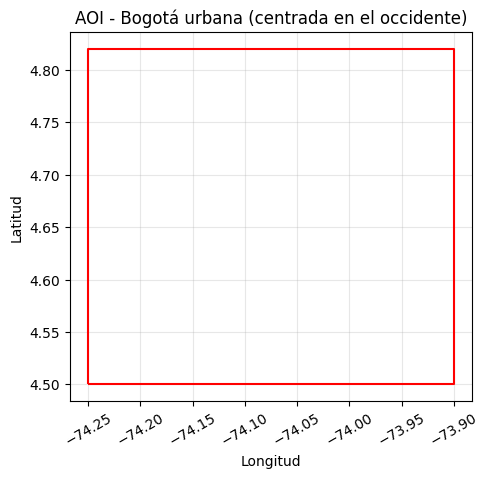

In [3]:
AOI_BBOX = [-74.25, 4.50, -73.90, 4.82]  # [min_lon, min_lat, max_lon, max_lat] para STAC
AOI_CENTER = (4.66, -74.07)
AOI_GEOM = box(*AOI_BBOX)
print("AOI bbox:", AOI_BBOX)
print("AOI center:", AOI_CENTER)
print("AOI desplazado al oeste para centrarse en el casco urbano de Bogotá.")

fig, ax = plt.subplots(figsize=(5, 5))
gpd.GeoSeries([AOI_GEOM], crs="EPSG:4326").boundary.plot(ax=ax, color="red")
ax.set_title("AOI - Bogotá urbana (centrada en el occidente)")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Búsqueda STAC — Sentinel-2 L2A sobre el AOI

Filtramos por:
- Colección `sentinel-2-l2a`
- Nubosidad `< 20%` (ordenado ascendente)
- Período 2024-2025
- Sólo 1 escena (la de menor cobertura de nubes)

In [4]:
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
print("Catálogo STAC abierto:", catalog.title)

def search_sentinel2(cloud_thr=20):
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=AOI_BBOX,
        datetime="2024-01-01/2025-12-31",
        query={"eo:cloud_cover": {"lt": cloud_thr}},
        sortby=[{"field": "eo:cloud_cover", "direction": "asc"}],
        max_items=30,
    )
    items = list(search.items())
    return items

items = search_sentinel2(cloud_thr=20)
if not items:
    print("Sin escenas con nubosidad < 20%. Ampliando a 40%...")
    items = search_sentinel2(cloud_thr=40)

if not items:
    raise RuntimeError("No se encontraron escenas Sentinel-2 sobre el AOI.")

# Bogotá cae en 4 tiles MGRS. Seleccionar el item con menor cc por tile.
from collections import defaultdict
by_tile = defaultdict(list)
for it in items:
    tile = it.properties.get("s2:mgrs_tile") or "unknown"
    by_tile[tile].append(it)

print(f"Escenas candidatas: {len(items)} en {len(by_tile)} tiles MGRS:")
selected = []
for t, lst in by_tile.items():
    best = min(lst, key=lambda x: x.properties.get("eo:cloud_cover", 100))
    selected.append(best)
    print(f"  {t}: {len(lst)} candidatas -> elegida cc={best.properties['eo:cloud_cover']:.2f}% ({best.id})")

# Ordenar por tile para que el log sea estable
selected.sort(key=lambda it: it.properties.get("s2:mgrs_tile", ""))
selected_signed = [pc.sign(it) for it in selected]
print(f"\n{len(selected)} items seleccionados (uno por tile):")
for it in selected:
    print(f"  {it.properties.get('s2:mgrs_tile')}  cc={it.properties['eo:cloud_cover']:.2f}%  bounds={it.bbox}")


Catálogo STAC abierto: Microsoft Planetary Computer STAC API


Escenas candidatas: 15 en 4 tiles MGRS:
  18NXL: 4 candidatas -> elegida cc=0.10% (S2B_MSIL2A_20240123T152649_R025_T18NXL_20240123T211252)
  18NWL: 5 candidatas -> elegida cc=0.06% (S2B_MSIL2A_20240123T152649_R025_T18NWL_20240123T211504)
  18NWK: 2 candidatas -> elegida cc=1.91% (S2B_MSIL2A_20240123T152649_R025_T18NWK_20240123T212703)
  18NXK: 4 candidatas -> elegida cc=2.46% (S2B_MSIL2A_20240123T152649_R025_T18NXK_20240123T211249)



4 items seleccionados (uno por tile):
  18NWK  cc=1.91%  bounds=[-75.0001803, 3.5300514, -74.010422, 4.5239245]
  18NWL  cc=0.06%  bounds=[-75.0001805, 4.4342413, -74.0090705, 5.4282254]
  18NXK  cc=2.46%  bounds=[-74.0996653, 3.5294383, -73.4130387, 4.5233632]
  18NXL  cc=0.10%  bounds=[-74.0986821, 4.4330942, -73.2163734, 5.4275513]


## 4. Descargar bandas B02, B03, B04, B08 y apilarlas

Cada banda se abre con `rioxarray.open_rasterio`, se recorta al AOI, se reproyecta a `EPSG:4326` y se apila en un `xarray.DataArray` con dimensión `band`.

In [5]:
BANDS = {"B02": "Blue", "B03": "Green", "B04": "Red", "B08": "NIR"}
arrays = []

for code, name in BANDS.items():
    band_arrays = []
    for it in selected_signed:
        href = it.assets[code].href
        print(f"  Cargando {code} ({name}) desde {it.properties.get('s2:mgrs_tile')}...")
        # Abrir y recortar en CRS nativo (UTM) ANTES del reproject
        da = rioxarray.open_rasterio(href, masked=True).squeeze("band", drop=True)
        # clip_box en UTM: la bbox lat/lon se transforma internamente al CRS del raster
        try:
            da_clip = da.rio.clip_box(*AOI_BBOX, crs="EPSG:4326")
        except Exception:
            da_clip = da
        band_arrays.append(da_clip)
    if len(band_arrays) == 1:
        merged = band_arrays[0]
    else:
        from rioxarray.merge import merge_arrays
        merged = merge_arrays(band_arrays, nodata=0)
    # Reproyectar ya mosaicado y recortado
    da_4326 = merged.rio.reproject("EPSG:4326")
    arrays.append(da_4326.assign_coords(band=code))
    del band_arrays

stack = xr.concat(arrays, dim="band")
stack = stack.assign_coords(band_name=("band", list(BANDS.values())))
print("\nStack shape:", stack.shape)
print("Stack CRS:", stack.rio.crs)
print("Stack bounds:", stack.rio.bounds())
print("Stack dtype:", stack.dtype)


  Cargando B02 (Blue) desde 18NWK...


  Cargando B02 (Blue) desde 18NWL...


  Cargando B02 (Blue) desde 18NXK...


  Cargando B02 (Blue) desde 18NXL...


  Cargando B03 (Green) desde 18NWK...


...

  Cargando B08 (NIR) desde 18NWK...


  Cargando B08 (NIR) desde 18NWL...


  Cargando B08 (NIR) desde 18NXK...


  Cargando B08 (NIR) desde 18NXL...



Stack shape: (4, 3556, 3887)
Stack CRS: EPSG:4326
Stack bounds: (-74.25038794439317, 4.4994429744475015, -73.89943073843078, 4.820514192456842)
Stack dtype: float32


## 5. Remuestrear a 256×256 y guardar GeoTIFF

Para que el archivo sea ligero y consistente con el resto del taller, se remuestrea a una grilla regular de 256×256 manteniendo EPSG:4326.

In [6]:
TARGET_HEIGHT = 256
TARGET_WIDTH = 256

stack_small = stack.rio.reproject(
    "EPSG:4326",
    shape=(TARGET_HEIGHT, TARGET_WIDTH),
    resampling=5,  # 5 = average
)
print("Shape remuestreada:", stack_small.shape)
print("Bounds remuestreada:", stack_small.rio.bounds())

out_tif = DATA_DIR / "bogota_sabana_sentinel2.tif"
stack_small.rio.to_raster(out_tif, compress="lzw")
print(f"\nGuardado: {out_tif} ({out_tif.stat().st_size/1024:.1f} KB)")

Shape remuestreada: (4, 256, 256)
Bounds remuestreada: (-74.25038794439317, 4.4994429744475015, -73.89943073843078, 4.820514192456842)

Guardado: ../data/bogota_sabana_sentinel2.tif (551.1 KB)


## 6. Vista previa del raster (RGB real)

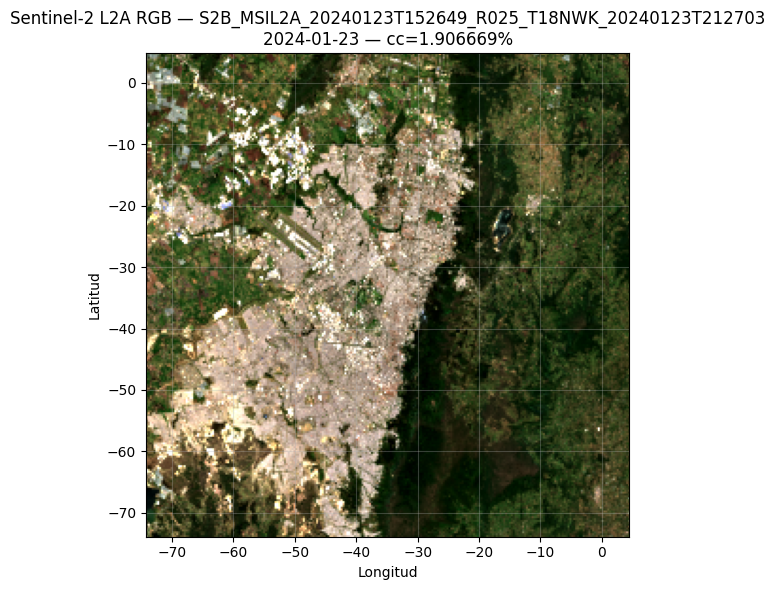

Preview guardada en ../../media/_preview_sentinel2.png


In [7]:
rgb = stack_small.sel(band=["B04", "B03", "B02"]).transpose("y", "x", "band").values
rgb = rgb.astype(np.float32)
vmin, vmax = np.nanpercentile(rgb, [2, 98])
rgb_stretched = np.clip((rgb - vmin) / (vmax - vmin), 0, 1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(rgb_stretched, extent=stack_small.rio.bounds(), origin="upper")
ax.set_title(f"Sentinel-2 L2A RGB — {selected[0].id}\n{selected[0].datetime.date()} — cc={selected[0].properties['eo:cloud_cover']}%")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.grid(True, alpha=0.3)
plt.tight_layout()
preview_path = DATA_DIR.parent.parent / "../../media" / "_preview_sentinel2.png"
preview_path.parent.mkdir(exist_ok=True)
plt.savefig(preview_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Preview guardada en {preview_path}")

## 7. OpenStreetMap — POIs (tourism) sobre Bogotá

Se hace geocoding de la ciudad y luego se descargan features con tag `tourism` dentro del polígono. Se filtran los puntos (geometría tipo `Point`) para simplificar la visualización.

In [8]:
ox.settings.timeout = 180

print("Geocodificando 'Bogotá, Colombia'...")
bogota = ox.geocode_to_gdf("Bogotá, Colombia")
print("Polígono AOI (Bogotá D.C.) obtenido:")
print(bogota[["display_name", "geometry"]].head(1).to_string())

region_path = DATA_DIR / "region.geojson"
bogota[["display_name", "geometry"]].to_file(region_path, driver="GeoJSON")
print(f"  → {region_path}")

print("\nDescargando POIs con tag 'tourism'...")
pois = None
for attempt in range(3):
    try:
        pois = ox.features_from_polygon(bogota.geometry.iloc[0], tags={"tourism": True})
        break
    except Exception as e:
        print(f"  intento {attempt+1} falló: {e}")
        time.sleep(5)

if pois is None or len(pois) == 0:
    raise RuntimeError("No se pudieron descargar POIs de OSM.")

pois_pts = pois[pois.geometry.type == "Point"].copy()
if len(pois_pts) < 5:
    pois_pts = pois_pts.head(5) if len(pois_pts) > 0 else pois.head(5)
pois_pts = pois_pts.head(5)  # Sólo 5 para que el mapa sea legible
pois_pts = pois_pts.reset_index(drop=True)
print(f"  {len(pois_pts)} POIs seleccionados")
print("  columnas disponibles:", list(pois_pts.columns)[:8])

name_col = "name" if "name" in pois_pts.columns else None
tourism_col = "tourism" if "tourism" in pois_pts.columns else None
keep_cols = ["geometry"] + ([name_col] if name_col else []) + ([tourism_col] if tourism_col else [])
keep_cols = list(dict.fromkeys(keep_cols))
pois_clean = pois_pts[keep_cols].copy()

poi_path = DATA_DIR / "puntos_interes.geojson"
pois_clean.to_file(poi_path, driver="GeoJSON")
print(f"  → {poi_path} ({poi_path.stat().st_size/1024:.1f} KB)")

Geocodificando 'Bogotá, Colombia'...
Polígono AOI (Bogotá D.C.) obtenido:
                                                         display_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

  5 POIs seleccionados
  columnas disponibles: ['geometry', 'name', 'tourism', 'wheelchair', 'wikidata', 'wikimedia_commons', 'wikipedia', 'name:es']
  → ../data/puntos_interes.geojson (1.0 KB)


## 8. OpenStreetMap — Red vial (sample) sobre Bogotá

Se descarga el grafo `drive` y se exporta una muestra de ~30 aristas como `LineString` representativas de vías principales.

In [9]:
print("Descargando grafo vial 'drive' de Bogotá...")
G = None
for attempt in range(3):
    try:
        G = ox.graph_from_polygon(bogota.geometry.iloc[0], network_type="drive", simplify=True)
        break
    except Exception as e:
        print(f"  intento {attempt+1} falló: {e}")
        time.sleep(5)

if G is None:
    raise RuntimeError("No se pudo descargar el grafo vial de OSM.")

edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
print(f"  edges totales: {len(edges)}")

edges_sample = edges.copy()
if "highway" in edges_sample.columns:
    # Priorizar vías principales
    main_types = ["primary", "secondary", "trunk", "motorway"]
    mask = edges_sample["highway"].astype(str).str.contains("|".join(main_types), na=False)
    if mask.sum() >= 10:
        edges_sample = edges_sample[mask]
edges_sample = edges_sample.head(30).reset_index(drop=True)
print(f"  edges muestreados: {len(edges_sample)}")

keep = ["geometry"]
for c in ["name", "highway", "length"]:
    if c in edges_sample.columns:
        keep.append(c)
edges_clean = edges_sample[keep].copy()

rutas_path = DATA_DIR / "rutas.geojson"
edges_clean.to_file(rutas_path, driver="GeoJSON")
print(f"  → {rutas_path} ({rutas_path.stat().st_size/1024:.1f} KB)")

Descargando grafo vial 'drive' de Bogotá...


  edges totales: 148262
  edges muestreados: 30
  → ../data/rutas.geojson (9.4 KB)


## 9. Verificación final

In [10]:
print("=" * 60)
print("RESUMEN DE DATOS DESCARGADOS")
print("=" * 60)
for p in sorted(DATA_DIR.glob("*")):
    print(f"  {p.name:40s}  {p.stat().st_size/1024:8.1f} KB")
print()
print("Provenance:")
print(f"  Sentinel-2 item id: {selected[0].id}")
print(f"  Sentinel-2 datetime: {selected[0].datetime}")
print(f"  Sentinel-2 cloud cover: {selected[0].properties['eo:cloud_cover']}%")
print(f"  Sentinel-2 platform: {selected[0].properties.get('platform')}")
print(f"  STAC catalog: planetarycomputer.microsoft.com")
print(f"  OSM: Nominatim geocoding + Overpass API")
print()
print("Próximo paso: ejecutar los notebooks 01-05 sobre estos datos.")

RESUMEN DE DATOS DESCARGADOS
  bogota_sabana_sentinel2.tif                  551.1 KB
  ndvi_bogota_sabana.tif                       283.9 KB
  ndvi_stats.json                                0.3 KB
  puntos_interes.geojson                         1.0 KB
  region.geojson                               225.0 KB
  rutas.geojson                                  9.4 KB

Provenance:
  Sentinel-2 item id: S2B_MSIL2A_20240123T152649_R025_T18NWK_20240123T212703
  Sentinel-2 datetime: 2024-01-23 15:26:49.024000+00:00
  Sentinel-2 cloud cover: 1.906669%
  Sentinel-2 platform: Sentinel-2B
  STAC catalog: planetarycomputer.microsoft.com
  OSM: Nominatim geocoding + Overpass API

Próximo paso: ejecutar los notebooks 01-05 sobre estos datos.
